# 1. Get data

In [ ]:
import pandas as pd

df = pd.read_csv("/content/spam_Emails_data.csv")
label_mapping = {"Spam":1, "Ham": 0}

df['label'] = df['label'].map(label_mapping)
df.head(1)

,label,text
0,1,viiiiiiagraaaa\nonly for the ones that want to...


In [ ]:
# import nltk
# nltk.download()

In [ ]:
import nltk

# Download đầy đủ — bao gồm punkt_tab (NLTK >= 3.8.2)
for pkg in [
    'punkt',
    'punkt_tab',         # bắt buộc với NLTK >= 3.8.2
    'stopwords',
    'wordnet',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',  # tagger mới
    'omw-1.4',           # WordNet đa ngôn ngữ
]:
    nltk.download(pkg, quiet=True)

## Prepocessing

## a. Data Quality

## Ver1:

In [ ]:
import pandas as pd
import numpy as np
import re
from typing import Dict, Any
import unicodedata

import pandas as pd
import re
import unicodedata

class TextCleaner:
    def __init__(self, series: pd.Series):
        self.s = series.astype(str)

    # 1. Normalize unicode
    def normalize_unicode(self):
        self.s = self.s.apply(lambda x: unicodedata.normalize("NFC", x))
        return self

    # 2. Lowercase
    def to_lower(self):
        self.s = self.s.str.lower()
        return self

    # 3. Remove newline & tabs
    def remove_linebreaks(self):
        self.s = self.s.str.replace(r"[\n\r\t]+", " ", regex=True)
        return self

    # 4. Fix repeated characters (viiiiagra → viagra)
    def fix_repeated_chars(self):
        self.s = self.s.str.replace(r"(.)\1{2,}", r"\1", regex=True)
        return self

    # 5. Remove special characters
    def remove_special_chars(self):
        self.s = self.s.str.replace(r"[^a-z0-9\s]", " ", regex=True)
        return self

    # 6. Remove extra spaces
    def clean_spaces(self):
        self.s = self.s.str.strip()
        self.s = self.s.str.replace(r"\s+", " ", regex=True)
        return self

    # 7. Remove very short tokens (noise words)
    def remove_short_words(self, min_len=3):
        self.s = self.s.apply(
            lambda x: " ".join([w for w in x.split() if len(w) >= min_len])
        )
        return self

    # 8. Full aggressive pipeline
    def aggressive_clean(self):
        return (
            self.normalize_unicode()
                .to_lower()
                .remove_linebreaks()
                .fix_repeated_chars()
                .remove_special_chars()
                .clean_spaces()
                .remove_short_words()
        )

    def get(self):
        return self.s

# Text Data Quality Check
class TextDataQuality:
    def __init__(self, df: pd.DataFrame, text_col: str):
        self.df = df.copy()
        self.col = text_col

        # Standardize basic representation
        self.series = self.df[self.col].astype(str)

    # -------------------------
    # 1. Completeness
    # -------------------------
    def check_completeness(self) -> Dict[str, Any]:
        s = self.df[self.col]

        return {
            "total_rows": len(s),
            "null_count": s.isna().sum(),
            "null_rate": s.isna().mean(),
            "empty_string_rate": (s == "").mean(),
            "whitespace_rate": s.astype(str).str.strip().eq("").mean(),
            "placeholder_rate": s.astype(str).str.lower().isin(
                ["na", "n/a", "none", "null", "unknown"]
            ).mean()
        }

    # -------------------------
    # 2. Validity (regex-based)
    # -------------------------
    def check_validity(self, pattern: str = None) -> Dict[str, Any]:
        if pattern is None:
            return {"message": "No pattern provided"}

        valid_mask = self.series.str.match(pattern, na=False)

        return {
            "valid_rate": valid_mask.mean(),
            "invalid_examples": self.series[~valid_mask].head(10).tolist()
        }

    # -------------------------
    # 3. Consistency
    # -------------------------
    def check_consistency(self) -> Dict[str, Any]:
        s = self.series

        return {
            "case_inconsistency_rate": (s != s.str.lower()).mean(),
            "leading_trailing_spaces_rate": (s != s.str.strip()).mean(),
            "multiple_spaces_rate": s.str.contains(r"\s{2,}", regex=True).mean()
        }

    # -------------------------
    # 4. Uniqueness / Duplication
    # -------------------------
    def check_uniqueness(self) -> Dict[str, Any]:
        s = self.series

        return {
            "n_unique": s.nunique(),
            "unique_rate": s.nunique() / len(s),
            "duplicate_rate": s.duplicated().mean(),
            "top_duplicates": s.value_counts().head(10).to_dict()
        }

    # -------------------------
    # 5. Length Analysis
    # -------------------------
    def check_length(self) -> Dict[str, Any]:
        length = self.series.str.len()

        return {
            "min_length": length.min(),
            "max_length": length.max(),
            "mean_length": length.mean(),
            "short_text_rate(<3)": (length < 3).mean(),
            "long_text_rate(>100)": (length > 100).mean()
        }

    # -------------------------
    # 6. Character / Pattern Issues
    # -------------------------
    def check_pattern(self) -> Dict[str, Any]:
        s = self.series

        return {
            "numeric_only_rate": s.str.match(r"^\d+$").mean(),
            "special_char_rate": s.str.contains(r"[^a-zA-Z0-9\s]", regex=True).mean(),
            "contains_digit_rate": s.str.contains(r"\d").mean()
        }

    # -------------------------
    # 7. Basic Semantic Check
    # -------------------------
    def check_semantic(self) -> Dict[str, Any]:
        s = self.series

        return {
            "single_word_rate": (s.str.split().str.len() == 1).mean(),
            "very_low_information_rate": (s.str.len() < 2).mean()
        }

    # -------------------------
    # 8. Run All Checks
    # -------------------------
    def run_all_checks(self) -> Dict[str, Any]:
        return {
            "completeness": self.check_completeness(),
            "consistency": self.check_consistency(),
            "uniqueness": self.check_uniqueness(),
            "length": self.check_length(),
            "pattern": self.check_pattern(),
            "semantic": self.check_semantic()
        }

    # -------------------------
    # 9. Generate Summary Table
    # -------------------------
    def summary_df(self) -> pd.DataFrame:
        results = self.run_all_checks()

        rows = []
        for category, metrics in results.items():
            for k, v in metrics.items():
                rows.append({
                    "category": category,
                    "metric": k,
                    "value": v
                })

        return pd.DataFrame(rows)

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

def stem_tokens(tokens: list[str]) -> list[str]:
    """
    Rút gọn token về dạng gốc (stem) bằng Porter.

    Mô tả:
        Áp dụng thuật toán Porter Stemmer để cắt
        hậu tố và đưa từ về dạng gốc heuristic
        (running -> run, phishing -> phish).
        Thống nhất các biến thể hình thái, phù hợp
        cho ứng dụng real-time nhờ chi phí tính toán
        thấp. Lưu ý: có thể sinh non-dictionary root
        (troubling -> troubl).

    Input:
        tokens (list[str]): Danh sách token chữ thường
                            đã loại stop word.

    Output:
        list[str]: Danh sách stem tương ứng.
                   Có thể không phải từ hợp lệ.

    Example:
        >>> stem_tokens(["phishing", "phished"])
        ['phish', 'phish']
    """
    return [stemmer.stem(token) for token in tokens]

# # --- Sử dụng ---
# tokens = ["running", "phishing", "phished", "invoices"]
# result = stem_tokens(tokens)
# print(result)
# Output: ['run', 'phish', 'phish', 'invoic']
# Lưu ý: 'invoic' là non-dictionary root

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag

nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag: str) -> str:
    """Chuyển đổi POS tag sang định dạng WordNet."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    return wordnet.NOUN

def lemmatize_tokens(tokens: list[str]) -> list[str]:
    """
    Chuyển token về dạng lemma dựa trên POS context.

    Mô tả:
        Áp dụng WordNet Lemmatizer kết hợp POS tagging
        để ánh xạ từ về lemma chính xác theo ngữ cảnh.
        Ví dụ: "better" -> "good" (adj), "saw" -> "see"
        (verb) vs "saw" -> "saw" (noun). Vượt trội hơn
        stemming về độ chính xác ngữ nghĩa, quan trọng
        cho phát hiện thuật ngữ phishing tinh vi.

    Input:
        tokens (list[str]): Danh sách token chữ thường.

    Output:
        list[str]: Danh sách lemma tương ứng.
                   Luôn là từ hợp lệ trong từ điển.

    Example:
        >>> lemmatize_tokens(["better", "accounts"])
        ['good', 'account']
    """
    tagged = pos_tag(tokens)
    return [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged
    ]

# # --- Sử dụng ---
# tokens = ["better", "meeting", "accounts", "saw"]
# result = lemmatize_tokens(tokens)
# print(result)
# # Output: ['good', 'meet', 'account', 'see']

In [ ]:
dq = TextDataQuality(df, "text")

# Run all checks
results = dq.run_all_checks()

# Get summary table
summary = dq.summary_df()

summary

,category,metric,value
0,completeness,total_rows,3338
1,completeness,null_count,0
2,completeness,null_rate,0.0
3,completeness,empty_string_rate,0.0
4,completeness,whitespace_rate,0.0
5,completeness,placeholder_rate,0.0
6,consistency,case_inconsistency_rate,0.0
7,consistency,leading_trailing_spaces_rate,0.317256
8,consistency,multiple_spaces_rate,0.000599
9,uniqueness,n_unique,3338


In [ ]:
df["clean_text"] = TextCleaner(df["text"]).aggressive_clean().get()

In [ ]:
import re
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk import pos_tag
from tqdm import tqdm                     # ← thêm mới [1/3]

for pkg in ['punkt_tab', 'stopwords', 'wordnet',
            'averaged_perceptron_tagger_eng', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ── Khởi tạo ──────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()
stemmer    = PorterStemmer()
STOP_WORDS = set(stopwords.words('english'))

PHISHING_SW = {"click", "here", "free", "offer", "limited"}
STOP_WORDS.update(PHISHING_SW)

MIN_TOKEN_LEN = 3

tqdm.pandas(desc="Processing")             # ← thêm mới [2/3]


# ── Các hàm xử lý ─────────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Bước 1 – Text Cleaning.
    Input : str  — văn bản thô (có thể chứa HTML, URL, ký tự đặc biệt)
    Output: str  — văn bản đã làm sạch, chuẩn hóa khoảng trắng
    """
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)          # xóa HTML tags
    text = re.sub(r'http\S+|www\.\S+', '', text)  # xóa URL
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # chỉ giữ chữ cái
    text = re.sub(r'\s+', ' ', text).strip()        # chuẩn hóa whitespace
    return text


def tokenize(text: str) -> list[str]:
    """
    Bước 2 – Tokenization.
    Input : str       — văn bản đã làm sạch
    Output: list[str] — danh sách token
    """
    return word_tokenize(text)


def lowercase(tokens: list[str]) -> list[str]:
    """
    Bước 3 – Lowercasing.
    Input : list[str] — token gốc
    Output: list[str] — token chữ thường
    """
    return [t.lower() for t in tokens]


def remove_stopwords(tokens: list[str]) -> list[str]:
    """
    Bước 4 – Stop Word Removal + lọc token ngắn.
    Input : list[str] — token chữ thường
    Output: list[str] — token có nghĩa, độ dài >= MIN_TOKEN_LEN
    """
    return [
        t for t in tokens
        if t not in STOP_WORDS and len(t) >= MIN_TOKEN_LEN
    ]


def _get_wn_pos(tag: str) -> str:
    """Chuyển POS tag (Penn Treebank) sang định dạng WordNet."""
    mapping = {'J': wordnet.ADJ, 'V': wordnet.VERB,
               'N': wordnet.NOUN, 'R': wordnet.ADV}
    return mapping.get(tag[0], wordnet.NOUN)


def lemmatize(tokens: list[str]) -> list[str]:
    """
    Bước 5a – Lemmatization (context-aware).
    Input : list[str] — token sau stop word removal
    Output: list[str] — lemma, luôn là từ hợp lệ trong từ điển
    """
    tagged = pos_tag(tokens)
    return [lemmatizer.lemmatize(w, _get_wn_pos(t)) for w, t in tagged]


def stem(tokens: list[str]) -> list[str]:
    """
    Bước 5b – Stemming (nhanh hơn lemmatize, dùng cho real-time).
    Input : list[str] — token sau stop word removal
    Output: list[str] — stem (có thể không phải từ hợp lệ)
    """
    return [stemmer.stem(t) for t in tokens]


# ── Pipeline chính ────────────────────────────────────────-

# ── Áp dụng lên DataFrame ──────────────────────────────────

def preprocess_str(text: str, use_lemma: bool = True) -> dict:
    """
    Chạy NLP pipeline cho 1 chuỗi văn bản.

    Input:
        text      (str)  — văn bản thô
        use_lemma (bool) — True = lemmatize, False = stem

    Output:
        dict với các key:
            'is_cleaned'          : int (luôn = 1)
            'n_stopwords_removed' : int
            'is_lemmatized'       : int (0 hoặc 1)
            'is_stemmed'          : int (0 hoặc 1)
            'text_tokens'         : list[str] — sau tokenize + lowercase
            'text_processed'      : str — chuỗi cuối cho TF-IDF
    """
    cleaned  = clean_text(text)
    tokens   = lowercase(tokenize(cleaned))

    before          = len(tokens)
    tokens_filtered = remove_stopwords(tokens)
    after           = len(tokens_filtered)

    tokens_final = lemmatize(tokens_filtered) if use_lemma else stem(tokens_filtered)

    return {
        'is_cleaned'          : 1,
        'n_stopwords_removed' : before - after,
        'is_lemmatized'       : int(use_lemma),
        'is_stemmed'          : int(not use_lemma),
        'text_tokens'         : tokens,
        'text_processed'      : ' '.join(tokens_final),
    }


def preprocess_dataframe(
    df: pd.DataFrame,
    text_col: str = 'clean_text',
    use_lemma: bool = True
) -> pd.DataFrame:
    """
    Chạy toàn bộ NLP pipeline trên một DataFrame.

    Input:
        df        (pd.DataFrame) — DataFrame chứa cột văn bản
        text_col  (str)          — tên cột chứa văn bản thô
        use_lemma (bool)         — True = lemmatize, False = stem

    Output:
        pd.DataFrame — df gốc + các cột mới:
            'is_cleaned'          : int (luôn = 1)
            'n_stopwords_removed' : int — số từ bị loại
            'is_lemmatized'       : int (0 hoặc 1)
            'is_stemmed'          : int (0 hoặc 1)
            'text_tokens'         : list[str]
            'text_processed'      : str — chuỗi cuối cho TF-IDF
    """
    result_df = pd.DataFrame(
        df[text_col].progress_apply(lambda x: preprocess_str(x, use_lemma=use_lemma)).tolist()
    )
    return pd.concat([df, result_df], axis=1)


def compute_stats(row: pd.Series) -> pd.Series:
    """
    Tính thống kê mô tả cho một dòng trong DataFrame.

    Input:
        row (pd.Series) — một dòng df có các cột:
            'clean_text'  : str       — văn bản thô gốc
            'text_tokens' : list[str] — sau tokenize + lowercase

    Output:
        pd.Series với 4 chỉ số:
            'n_chars'        : int — số ký tự (kể cả khoảng trắng)
            'n_unique_chars' : int — số ký tự unique (bỏ khoảng trắng)
            'n_words'        : int — số từ (token) sau tokenize
            'n_unique_words' : int — số từ unique sau tokenize
    """
    raw_text   = str(row['clean_text'])
    tokens_all = row['text_tokens']

    return pd.Series({
        'n_chars'       : len(raw_text),
        'n_unique_chars': len(set(raw_text.replace(' ', ''))),
        'n_words'       : len(tokens_all),
        'n_unique_words': len(set(tokens_all)),
    })


def add_stats_to_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Thêm các cột thống kê vào DataFrame đã preprocessing.

    Input:
        df (pd.DataFrame) — df sau khi đã chạy preprocess_dataframe()
                            (phải có cột 'clean_text', 'text_tokens')

    Output:
        pd.DataFrame — df gốc + 4 cột mới:
            'n_chars'        : số ký tự văn bản thô
            'n_unique_chars' : số ký tự unique (bỏ space)
            'n_words'        : số từ sau tokenize
            'n_unique_words' : số từ unique sau tokenize
    """
    stats = df.apply(compute_stats, axis=1)
    return pd.concat([df, stats], axis=1)


# ── Chạy thử ───────────────────────────────────────────────
if __name__ == "__main__":
    df = preprocess_dataframe(df, text_col='clean_text', use_lemma=True)
    df = add_stats_to_df(df)

Processing: 100%|██████████| 3338/3338 [01:43<00:00, 32.25it/s]


In [ ]:
df.to_csv('process_email_data.csv')

## EDA

In [ ]:
# df.head()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/process_email_data.csv')

In [ ]:
df

,Unnamed: 0,label,text,clean_text,is_cleaned,n_stopwords_removed,is_lemmatized,is_stemmed,text_tokens,text_processed,n_chars,n_unique_chars,n_words,n_unique_words
0,0,1,viiiiiiagraaaa\nonly for the ones that want to...,viagra only for the ones that want make her sc...,1,5,1,0,"['viagra', 'only', 'for', 'the', 'ones', 'that...",viagra one want make scream prodigy scrawny cr...,374,24,51,51
1,1,0,got ice thought look az original message ice o...,got ice thought look original message ice oper...,1,0,1,0,"['got', 'ice', 'thought', 'look', 'original', ...",get ice think look original message ice operat...,524,24,58,46
2,2,1,yo ur wom an ne eds an escapenumber in ch ma n...,wom eds escapenumber arn here not ific ati ons...,1,3,1,0,"['wom', 'eds', 'escapenumber', 'arn', 'here', ...",wom ed escapenumber arn ific ati ons escapelon...,138,22,20,16
3,3,1,start increasing your odds of success & live s...,start increasing your odds success live sexual...,1,15,1,0,"['start', 'increasing', 'your', 'odds', 'succe...",start increase odds success live sexually heal...,293,24,48,42
4,4,0,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...,1,13,1,0,"['author', 'jra', 'date', 'escapenumber', 'esc...",author jra date escapenumber escapenumber esca...,2941,24,407,89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193847,193847,0,on escapenumber escapenumber escapenumber rob ...,escapenumber escapenumber escapenumber rob dix...,1,33,1,0,"['escapenumber', 'escapenumber', 'escapenumber...",escapenumber escapenumber escapenumber rob dix...,785,23,128,81
193848,193848,1,we have everything you need escapelong cialesc...,have everything you need escapelong cialescape...,1,5,1,0,"['have', 'everything', 'you', 'need', 'escapel...",everything need escapelong cialescapenumbers s...,558,22,44,36
193849,193849,0,hi quick question say i have a date variable i...,quick question say have date variable data fra...,1,22,1,0,"['quick', 'question', 'say', 'have', 'date', '...",quick question say date variable data frame ma...,555,26,91,66
193850,193850,1,thank you for your loan request which we recie...,thank you for your loan request which recieved...,1,18,1,0,"['thank', 'you', 'for', 'your', 'loan', 'reque...",thank loan request recieved escapenumber escap...,389,24,57,45


In [ ]:
# Calculate the percentage of stopwords removed
df['perc_stopwords_removed'] = df['n_stopwords_removed'] / df['n_words']

# Calculate the percentage of unique words
df['perc_unique_words'] = df['n_unique_words'] / df['n_words']

# 1. Ratio / Density features
df['stopword_ratio'] = (df['n_words'] - df['n_stopwords_removed']) / df['n_words']
df['unique_word_ratio'] = df['n_unique_words'] / df['n_words']
df['unique_char_ratio'] = df['n_unique_chars'] / df['n_chars']
df['avg_word_length'] = df['n_chars'] / df['n_words']

# 2. Length normalization
df['log_words'] = np.log1p(df['n_words'])
df['log_chars'] = np.log1p(df['n_chars'])
df['chars_per_unique_word'] = df['n_chars'] / df['n_unique_words']

# 4. Repetition / redundancy features
df['repetition_ratio'] = 1 - (df['n_unique_words'] / df['n_words'])
df['char_repetition'] = 1 - (df['n_unique_chars'] / df['n_chars'])

# 5. Stopword behavior
df['content_ratio'] = df['n_stopwords_removed'] / df['n_words']
df['stopword_vs_unique'] = (df['n_words'] - df['n_stopwords_removed']) / df['n_unique_words']

# 6. Interaction features
df['complexity'] = df['unique_word_ratio'] * df['avg_word_length']
df['info_density'] = df['n_unique_words'] / df['n_chars']

# Display the DataFrame with new features
display(df.head())

,Unnamed: 0,label,text,clean_text,is_cleaned,n_stopwords_removed,is_lemmatized,is_stemmed,text_tokens,text_processed,...,avg_word_length,log_words,log_chars,chars_per_unique_word,repetition_ratio,char_repetition,content_ratio,stopword_vs_unique,complexity,info_density
0,0,1,viiiiiiagraaaa\nonly for the ones that want to...,viagra only for the ones that want make her sc...,1,5,1,0,"['viagra', 'only', 'for', 'the', 'ones', 'that...",viagra one want make scream prodigy scrawny cr...,...,7.333333,3.951244,5.926926,7.333333,0.000000,0.935829,0.098039,0.901961,7.333333,0.136364
1,1,0,got ice thought look az original message ice o...,got ice thought look original message ice oper...,1,0,1,0,"['got', 'ice', 'thought', 'look', 'original', ...",get ice think look original message ice operat...,...,9.034483,4.077537,6.263398,11.391304,0.206897,0.954198,0.000000,1.260870,7.165279,0.087786
2,2,1,yo ur wom an ne eds an escapenumber in ch ma n...,wom eds escapenumber arn here not ific ati ons...,1,3,1,0,"['wom', 'eds', 'escapenumber', 'arn', 'here', ...",wom ed escapenumber arn ific ati ons escapelon...,...,6.900000,3.044522,4.934474,8.625000,0.200000,0.840580,0.150000,1.062500,5.520000,0.115942
3,3,1,start increasing your odds of success & live s...,start increasing your odds success live sexual...,1,15,1,0,"['start', 'increasing', 'your', 'odds', 'succe...",start increase odds success live sexually heal...,...,6.104167,3.891820,5.683580,6.976190,0.125000,0.918089,0.312500,0.785714,5.341146,0.143345
4,4,0,author jra date escapenumber escapenumber esca...,author jra date escapenumber escapenumber esca...,1,13,1,0,"['author', 'jra', 'date', 'escapenumber', 'esc...",author jra date escapenumber escapenumber esca...,...,7.226044,6.011267,7.986845,33.044944,0.781327,0.991840,0.031941,4.426966,1.580142,0.030262


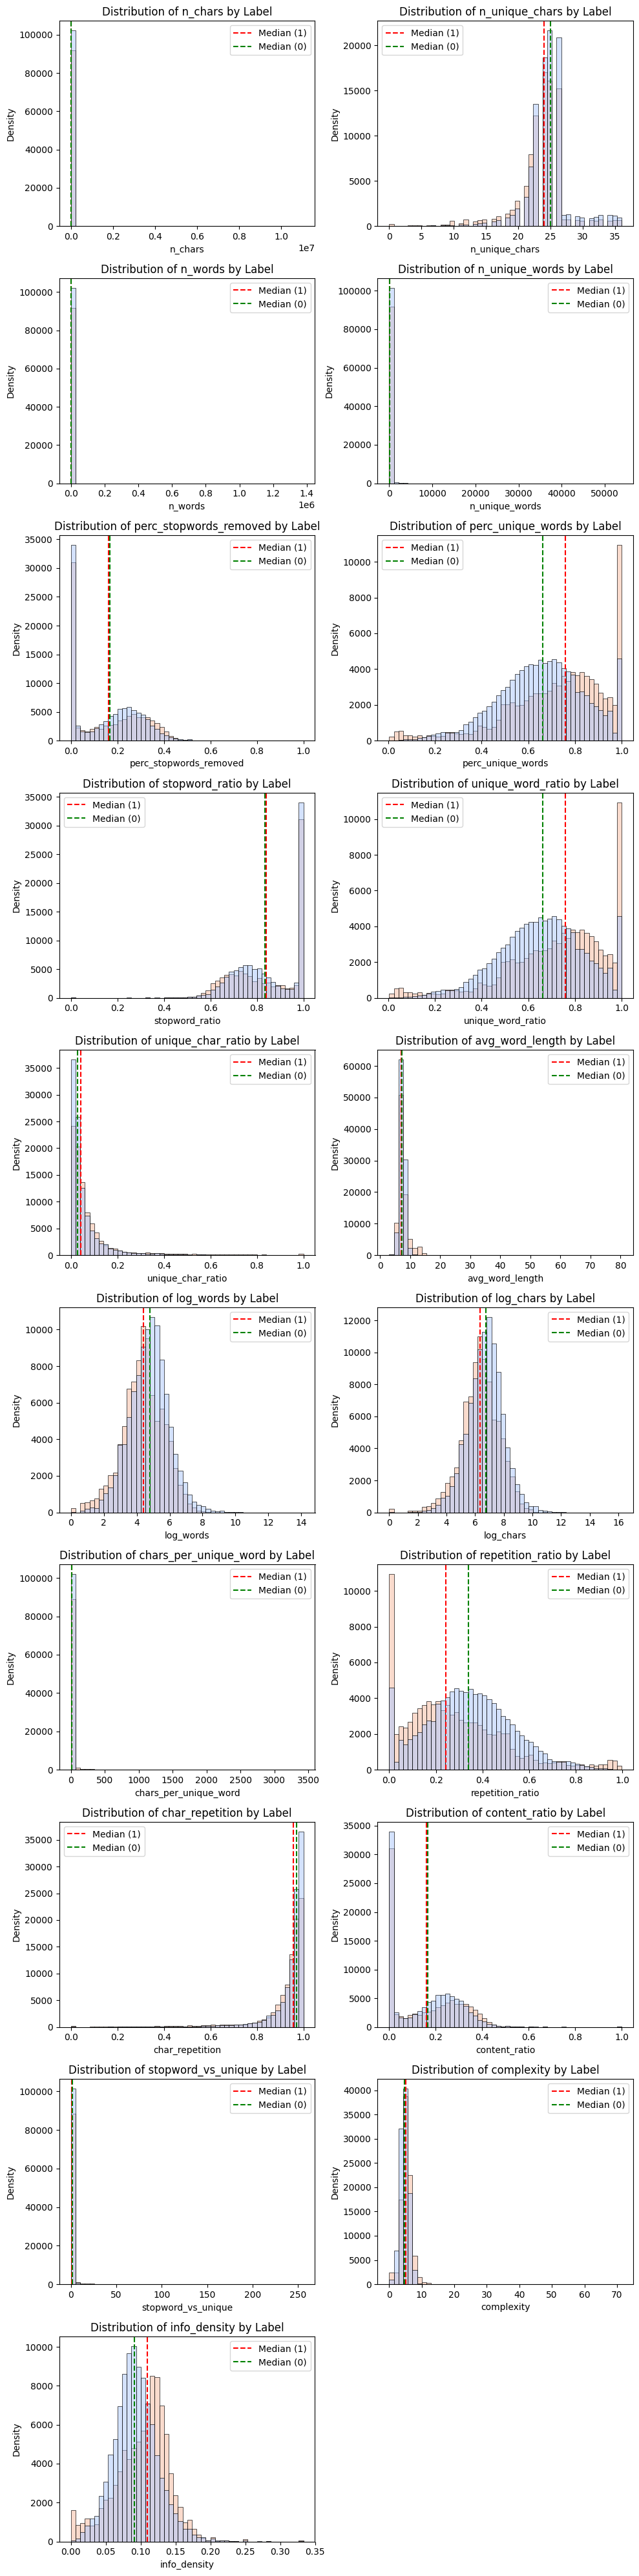

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all numeric columns initially
numeric_cols_all = df.select_dtypes(include=['number']).columns.tolist()

# Define columns to remove (label and meta-features used for preprocessing flags)
remove_cols = ['Unnamed: 0', 'is_cleaned', 'is_lemmatized', 'is_stemmed', 'n_stopwords_removed']

# Filter numeric columns to only include the ones we want to plot
numeric_cols = [col for col in numeric_cols_all if col not in remove_cols + ['label']]

# Calculate 99th percentiles for each numeric column by label
percentile_99 = df.groupby('label')[numeric_cols].apply(lambda x: x.quantile(0.995))
percentile_50 = df.groupby('label')[numeric_cols].apply(lambda x: x.quantile(0.5))


# Determine grid size dynamically
n_plots = len(numeric_cols)
n_cols = 2  # You can adjust the number of columns
n_rows = (n_plots + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 4))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(data=df, x=col, hue='label', kde=False, bins=50, common_norm=False, palette='coolwarm')

    # Add vertical line for 99th percentile for each label
    for label_val, color in zip(df['label'].unique(), ['red', 'green']):
        p50 = percentile_50.loc[label_val, col]
        plt.axvline(p50, color=color, linestyle='--', label=f'Median ({label_val})')

    plt.title(f'Distribution of {col} by Label')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()

plt.tight_layout()
plt.show()

## Modelling

In [ ]:
df = df.drop(columns=remove_cols + ['text','clean_text']).dropna(subset=['text_processed'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=50000
)

X_train, X_test, y_train, y_test = train_test_split(
    df['text_processed'],
    df['label'],

    test_size=0.2,
    random_state=42
)

In [ ]:
X_train.head()

,text_processed
108220,jay louis dreyfus energy service want get plac...
179187,understand correctly perl script escapenumber ...
101869,escapenumbernd july escapenumber winner comput...
52607,escapenumber escapenumber escapenumber adrian ...
164128,saf acy est yof arm inc eyo xualdes spe umeby ...


In [ ]:
# # Extract text documents from the DataFrame
# document_texts = df['text'].tolist()

# # Compute TF scores
# tf_scores_df = compute_tf(document_texts)

# # Compute IDF scores
# idf_scores_df = compute_idf(document_texts)

# # Compute TF-IDF scores
# tf_idf_scores_df = compute_tf_idf(tf_scores_df, idf_scores_df)

# # Convert the list of dictionaries to a Pandas DataFrame for better readability
# tf_idf_df = pd.DataFrame(tf_idf_scores_df)

# # Display the first few rows of the TF-IDF DataFrame
# print("TF-IDF scores (first 5 rows):")
# print(tf_idf_df.head())

In [ ]:
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [ ]:
X_train_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12174660 stored elements and shape (154855, 50000)>

In [ ]:
X_test_vec

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3008510 stored elements and shape (38714, 50000)>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score,
    ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV

# ── 1. ĐỊNH NGHĨA CÁC MODELS ─────────────────────────────────────────────────
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes":         MultinomialNB(),
    "SVM":                 CalibratedClassifierCV(LinearSVC(random_state=42)),  # wrap để có predict_proba
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost":             XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
}

# ── 2. TRAIN & EVALUATE ───────────────────────────────────────────────────────
results = []

for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # Train
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred      = model.predict(X_test_vec)
    y_prob      = model.predict_proba(X_test_vec)[:, 1]  # score lớp positive

    # Metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    ap     = average_precision_score(y_test, y_prob)      # Area under PR curve

    pos = report["1"]   # metrics cho lớp positive (đổi "1" nếu label khác)
    results.append({
        "Model":     name,
        "Precision": pos["precision"],# Success Metric
        "Recall":    pos["recall"],
        "F1":        pos["f1-score"],
        "AP (AUC-PR)": ap,
        "Accuracy":  report["accuracy"],
    })

    print(classification_report(y_test, y_pred))
    print(f"  ► Average Precision (AUC-PR): {ap:.4f}")

# ── 3. BẢNG TỔNG HỢP ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).sort_values("AP (AUC-PR)", ascending=False)
df_results = df_results.reset_index(drop=True)

print("\n" + "="*65)
print("  BẢNG SO SÁNH CÁC MODELS (sắp xếp theo AUC-PR)")
print("="*65)
print(df_results.round(4).to_string(index=False))


  Logistic Regression
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     20368
           1       0.97      0.98      0.98     18346

    accuracy                           0.98     38714
   macro avg       0.98      0.98      0.98     38714
weighted avg       0.98      0.98      0.98     38714

  ► Average Precision (AUC-PR): 0.9958

  Naive Bayes
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     20368
           1       0.97      0.92      0.95     18346

    accuracy                           0.95     38714
   macro avg       0.95      0.95      0.95     38714
weighted avg       0.95      0.95      0.95     38714

  ► Average Precision (AUC-PR): 0.9920

  SVM
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     20368
           1       0.98      0.99      0.99     18346

    accuracy                           0.99     38714
   ma

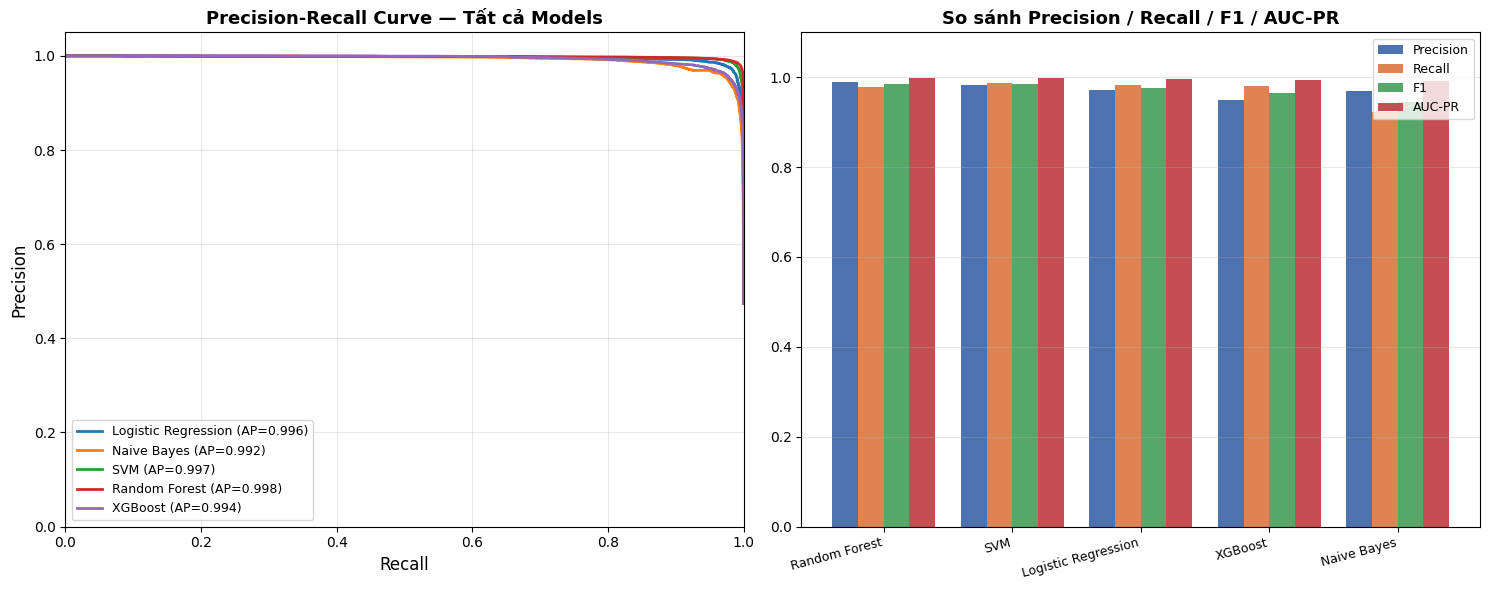

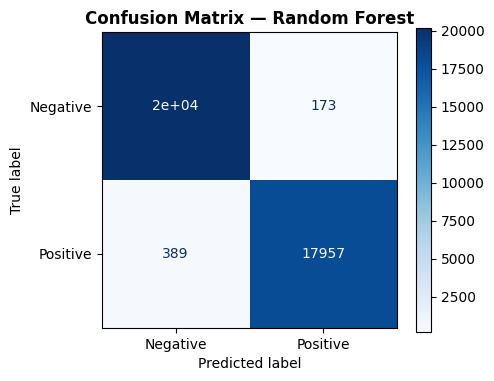


✅ Model tốt nhất theo AUC-PR: Random Forest


In [ ]:
# ── 4. PRECISION-RECALL CURVE (tất cả models trên 1 biểu đồ) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
for name, model in models.items():
    y_prob = model.predict_proba(X_test_vec)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax1.plot(recall, precision, label=f"{name} (AP={ap:.3f})", linewidth=2)

ax1.set_xlabel("Recall", fontsize=12)
ax1.set_ylabel("Precision", fontsize=12)
ax1.set_title("Precision-Recall Curve — Tất cả Models", fontsize=13, fontweight="bold")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.05])

# ── 5. BAR CHART SO SÁNH METRICS ─────────────────────────────────────────────
ax2 = axes[1]
x   = np.arange(len(df_results))
w   = 0.2

ax2.bar(x - w,   df_results["Precision"],   w, label="Precision",   color="#4C72B0")
ax2.bar(x,       df_results["Recall"],      w, label="Recall",      color="#DD8452")
ax2.bar(x + w,   df_results["F1"],          w, label="F1",          color="#55A868")
ax2.bar(x + 2*w, df_results["AP (AUC-PR)"], w, label="AUC-PR",      color="#C44E52")

ax2.set_xticks(x + w/2)
ax2.set_xticklabels(df_results["Model"], rotation=15, ha="right", fontsize=9)
ax2.set_ylim([0, 1.1])
ax2.set_title("So sánh Precision / Recall / F1 / AUC-PR", fontsize=13, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. CONFUSION MATRIX (model tốt nhất) ────────────────────────────────────
best_name  = df_results.iloc[0]["Model"]
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_vec)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Negative", "Positive"],
    cmap="Blues", ax=ax
)
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n✅ Model tốt nhất theo AUC-PR: {best_name}")

In [ ]:
y_test.value_counts()

,count
label,
0,20368
1,18346
